<a href="https://colab.research.google.com/github/shdezg2000/assessment-biomarkers/blob/main/notebooks/assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/shdezg2000/assessment-biomarkers.git
%cd assessment-biomarkers

Cloning into 'assessment-biomarkers'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 10 (delta 0), reused 10 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 29.17 KiB | 3.65 MiB/s, done.
/content/assessment-biomarkers


In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.4 MB/s eta 0:00:00


# Assessment: Clasificación de Biomarcadores para Alzheimer

## Contexto

El Alzheimer (AD) es una enfermedad neurodegenerativa que actualmente se diagnostica principalmente por síntomas clínicos, cuando el daño neuronal ya es significativo. El framework **AT(N)** — Amyloid (A), Tau (T), Neurodegeneration (N) — permite categorizar biomarcadores según el proceso patológico que reflejan, abriendo la puerta a diagnósticos más tempranos basados en biología.

En este assessment trabajarás con un dataset sintético de biomarcadores de **líquido cefalorraquídeo (CSF)** y **sangre (plasma)** para clasificar pacientes en tres categorías:

- **NC** — Normal Cognition (cognición normal)
- **MCI** — Mild Cognitive Impairment (deterioro cognitivo leve)
- **AD** — Alzheimer's Disease

### Lo que evaluamos

Buscamos entender **cómo piensas**, **cómo abordas problemas**, y **cómo comunicas tus decisiones**.

---

## Instrucciones

1. Completa las **tres partes** de este notebook.
2. Escribe tu código en las celdas indicadas.
3. Responde las preguntas abiertas en celdas de Markdown.
4. Cuando termines, haz **push** a tu fork y envía la liga del repositorio.

**Puedes usar:** documentación, Google, recursos en línea. Evita usar IA para generar el código. Preferimos ver TU razonamiento :)

---
## Setup

Ejecuta esta celda para cargar las dependencias y el dataset. **No modifiques esta sección.**

In [ ]:
# ============================================================
# SETUP — No modificar esta celda
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Carga del dataset
df = pd.read_csv('data/biomarker_data.csv')
print(f"Dataset cargado: {df.shape[0]} muestras, {df.shape[1]} columnas")
print(f"\nPrimeras filas:")
df.head()

Dataset cargado: 485 muestras, 15 columnas

Primeras filas:


,PATIENT_ID,CSF_AB42,CSF_TAU,CSF_PTAU,PLASMA_PTAU217,PLASMA_AB42,PLASMA_AB40,PLASMA_NFL,PLASMA_GFAP,AGE,SEX,EDUCATION_YEARS,DIAGNOSIS,PLASMA_AB42_AB40_RATIO,PLASMA_PTAU217_AB42_RATIO
0,SYNTH_0000,354.2744,517.3442,64.1150,3.3858,12.7293,154.3215,25.0867,165.6137,84.5,0,17,AD,0.0825,0.2660
1,SYNTH_0001,315.3551,341.0668,75.3082,3.1213,8.7416,171.4600,30.4924,102.2614,80.0,1,20,AD,0.0510,0.3571
2,SYNTH_0002,577.1411,67.8422,9.3547,2.1406,22.8720,165.3934,15.8548,NaN,69.5,1,19,NC,0.1383,0.0936
3,SYNTH_0003,280.1151,341.9984,44.5340,2.9849,12.3354,147.6431,42.6316,121.6778,74.5,1,18,AD,0.0835,0.2420
4,SYNTH_0004,164.2937,494.5870,57.8664,1.1941,14.5843,165.7577,28.2579,277.3425,77.9,1,17,AD,0.0880,0.0819


### Variables del dataset

| Variable | Fuente | Descripción |
|---|---|---|
| `CSF_AB42` | CSF | Beta-amiloide 1-42 (pg/mL) — marcador de amiloidosis |
| `CSF_TAU` | CSF | Tau total (pg/mL) — marcador de neurodegeneración |
| `CSF_PTAU` | CSF | Tau fosforilada (pg/mL) — marcador de taupatía |
| `PLASMA_PTAU217` | Sangre | Fosfo-tau 217 (pg/mL) — marcador emergente de tau |
| `PLASMA_AB42` | Sangre | Beta-amiloide 42 en plasma (pg/mL) |
| `PLASMA_AB40` | Sangre | Beta-amiloide 40 en plasma (pg/mL) |
| `PLASMA_NFL` | Sangre | Neurofilamento ligero (pg/mL) — daño axonal |
| `PLASMA_GFAP` | Sangre | Proteína ácida fibrilar glial (pg/mL) — astrogliosis |
| `AGE` | Demográfica | Edad del paciente |
| `SEX` | Demográfica | Sexo (0=Femenino, 1=Masculino) |
| `EDUCATION_YEARS` | Demográfica | Años de educación |
| `PLASMA_AB42_AB40_RATIO` | Derivada | Ratio Aβ42/Aβ40 en plasma |
| `PLASMA_PTAU217_AB42_RATIO` | Derivada | Ratio pTau217/Aβ42 en plasma |
| `DIAGNOSIS` | Target | NC, MCI, o AD |

---
# PARTE 1: Exploración de Datos (30%)

Antes de construir cualquier modelo, necesitas entender los datos con los que trabajas.

### 1.1 Análisis descriptivo

Explora el dataset y responde:
- ¿Cuántas muestras hay por clase?
- ¿Hay valores faltantes? ¿En qué columnas?
- ¿Cuáles son las estadísticas descriptivas de los biomarcadores por grupo diagnóstico?

In [ ]:
df.shape

(485, 15)

In [ ]:
df['DIAGNOSIS'].value_counts()

,count
DIAGNOSIS,
NC,250
MCI,150
AD,85


In [ ]:
df.isnull().sum()

,0
PATIENT_ID,0
CSF_AB42,23
CSF_TAU,21
CSF_PTAU,31
PLASMA_PTAU217,0
PLASMA_AB42,0
PLASMA_AB40,0
PLASMA_NFL,25
PLASMA_GFAP,26
AGE,0


In [ ]:
df.groupby('DIAGNOSIS').describe()

CSF_AB42                                                         \
             count        mean         std       min        25%       50%   
DIAGNOSIS                                                                   
AD            83.0  342.031059   84.833987  125.1745  290.56635  362.1805   
MCI          141.0  524.664837  158.248173  115.2704  425.22300  507.1040   
NC           238.0  681.889216  115.994072  365.6306  599.22345  687.4706   

                                 CSF_TAU              ...  \
                  75%        max   count        mean  ...   
DIAGNOSIS                                             ...   
AD         397.510650   538.8145    82.0  393.981630  ...   
MCI        615.204700   950.8854   143.0  258.627324  ...   
NC         752.656625  1142.3278   239.0  180.244514  ...   

          PLASMA_AB42_AB40_RATIO         PLASMA_PTAU217_AB42_RATIO            \
                             75%     max                     count      mean   
DIAGNOSIS                                                                      
AD                      0.098800  0.1730                      85.0  0.337211   
MCI                     0.132975  0.3204                     150.0  0.145173   
NC                      0.147000  0.2376                     250.0  0.071640   

                                                                 
                std     min       25%      50%      75%     max  
DIAGNOSIS                                                        
AD         0.220970  0.0202  0.245400  0.31790  0.36510  1.9194  
MCI        0.083810 -0.0107  0.084700  0.13855  0.19035  0.4325  
NC         0.031656 -0.0007  0.049425  0.06735  0.09170  0.2206  

[3 rows x 104 columns]

### 1.2 Visualización exploratoria

Crea al menos **dos visualizaciones** que te ayuden a entender la relación entre los biomarcadores y el diagnóstico. Por ejemplo: distribuciones por clase, boxplots, scatter plots, heatmap de correlaciones, etc.

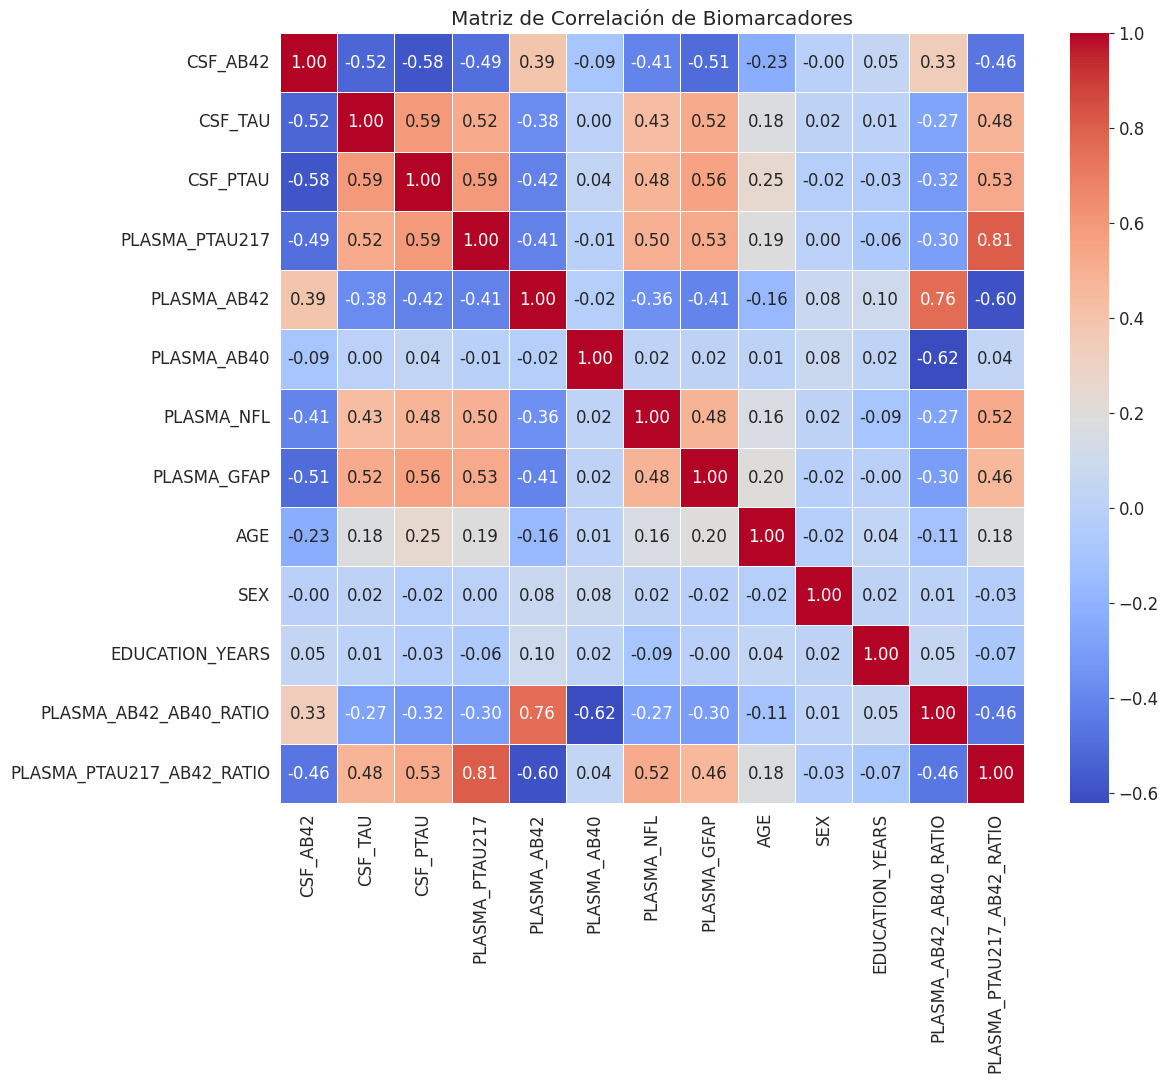

In [ ]:
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación de Biomarcadores')
plt.show()

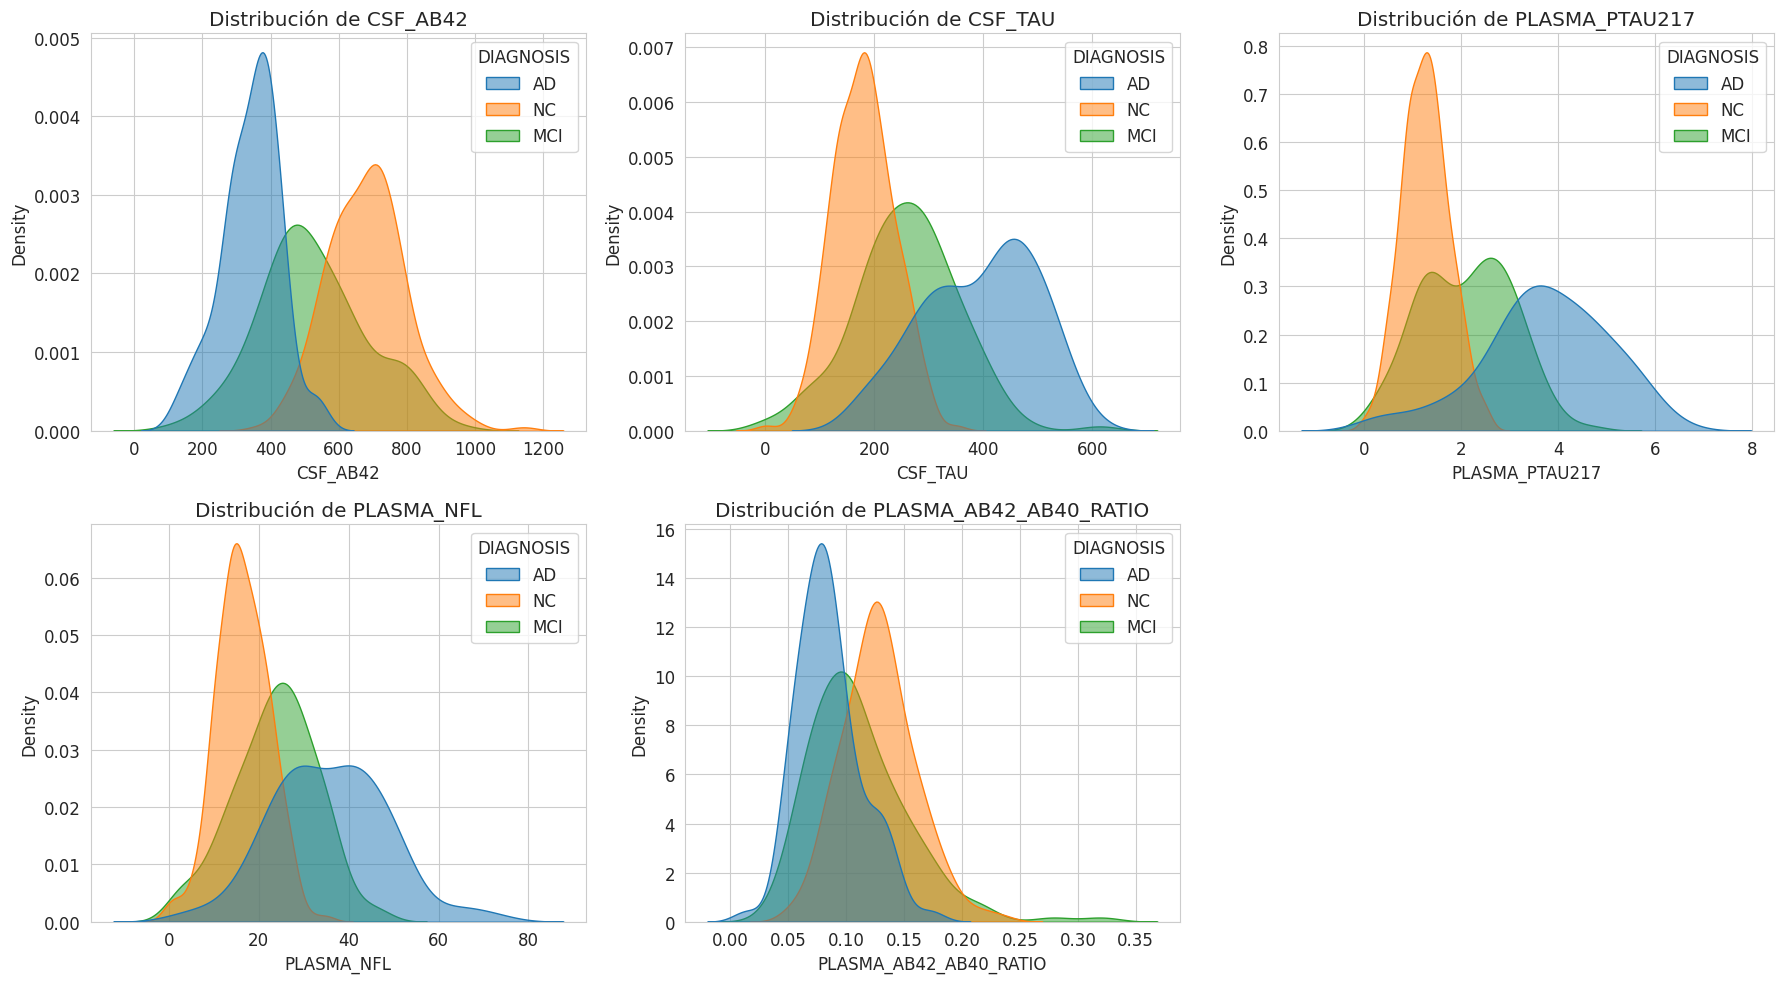

In [ ]:
# Variables numéricas clave
features = ['CSF_AB42', 'CSF_TAU', 'PLASMA_PTAU217', 'PLASMA_NFL', 'PLASMA_AB42_AB40_RATIO']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue='DIAGNOSIS', fill=True, ax=axes[i], common_norm=False, alpha=0.5)
    axes[i].set_title(f'Distribución de {col}')

if len(features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### 1.3 Pregunta abierta

Basándote en tu exploración, responde en la celda de abajo:

1. **¿Qué biomarcadores parecen ser los más útiles para distinguir entre las tres clases? ¿Por qué?**
2. **¿Qué desafíos anticipas para clasificar correctamente la clase MCI?**
3. **¿Cómo planeas manejar los valores faltantes y por qué elegiste ese enfoque?**

Los biomarcadores parecen ser lo más útiles para distinguir entre las tres clases son los siguientes:

PLASMA_PTAU217; Hay muy poco traslape, lo que significa que este valor por sí solo casi puede diagnosticar a un paciente.

CSF_TAU y CSF_AB42; los pacientes con AD (azul) se concentran en valores bajos, mientras que los sanos (naranja) en valores altos.

PLASMA_NFL; Es excelente para separar NC de AD, es menos específico para etapas intermedias.

El principal desafío técnico radica en la clasificación de la etapa MCI, ya que las gráficas de densidad muestran un solapamiento significativo entre las distribuciones de los grupos NC y AD, lo que refleja la naturaleza transitoria

Para abordar la presencia de valores faltantes, aplicaria una imputación por mediana en las variables numéricas, elegiria este enfoque sobre la eliminación de registros para preservar la integridad estadística del dataset

---
# PARTE 2: Modelado (40%)

En esta sección vas a entrenar modelos de clasificación. Te proporcionamos un **modelo baseline con overfitting intencional**. Tu tarea es entenderlo, identificar los problemas, y proponer una mejora.

### 2.1 Preparación de datos

Prepara los datos para modelado: maneja los valores faltantes, selecciona features, y separa features de target.

In [ ]:
X = df.drop(columns=['DIAGNOSIS'])
y = df['DIAGNOSIS']

X_numeric = X.select_dtypes(include=['float64', 'int64'])

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42, stratify=y
)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"Forma del set de entrenamiento: {X_train_final.shape}")
print(f"Forma del set de prueba: {X_test_final.shape}")

Forma del set de entrenamiento: (388, 13)
Forma del set de prueba: (97, 13)


### 2.2 Modelo Baseline (overfitting intencional)

Ejecuta el siguiente modelo baseline. Este modelo tiene **problemas intencionales** que deberás identificar.

In [ ]:
# ============================================================
# BASELINE — Ejecuta esta celda sin modificar
# ============================================================
# NOTA: Este modelo tiene problemas intencionales.
# Tu tarea en 2.3 es identificarlos y proponer mejoras.

# Preparación rápida del baseline (usa dropna para simplificar)
df_baseline = df.dropna().copy()
feature_cols = [c for c in df_baseline.columns if c not in ['PATIENT_ID', 'DIAGNOSIS']]
X_base = df_baseline[feature_cols].values
y_base = LabelEncoder().fit_transform(df_baseline['DIAGNOSIS'])

# Random Forest con hiperparámetros que promueven overfitting
rf_overfit = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,        # Sin límite de profundidad
    min_samples_split=2,   # Mínimo para split
    min_samples_leaf=1,    # Mínimo en hojas
    max_features=None,     # Usa TODAS las features en cada split
    class_weight=None,     # No ajusta por desbalance
    random_state=42
)

# Evaluación con cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_base = cross_validate(
    rf_overfit, X_base, y_base, cv=cv,
    scoring=['accuracy', 'f1_macro'],
    return_train_score=True
)

print("="*55)
print("BASELINE MODEL — Random Forest (overfit config)")
print("="*55)
print(f"Train Accuracy:      {scores_base['train_accuracy'].mean():.4f} ± {scores_base['train_accuracy'].std():.4f}")
print(f"Validation Accuracy: {scores_base['test_accuracy'].mean():.4f} ± {scores_base['test_accuracy'].std():.4f}")
print(f"Train F1 (macro):    {scores_base['train_f1_macro'].mean():.4f} ± {scores_base['train_f1_macro'].std():.4f}")
print(f"Validation F1 (macro): {scores_base['test_f1_macro'].mean():.4f} ± {scores_base['test_f1_macro'].std():.4f}")
print(f"\nGap train-val accuracy: {(scores_base['train_accuracy'].mean() - scores_base['test_accuracy'].mean()):.4f}")
print("\n⚠️  Observa el gap entre train y validation. ¿Qué indica esto?")

BASELINE MODEL — Random Forest (overfit config)
Train Accuracy:      1.0000 ± 0.0000
Validation Accuracy: 0.9054 ± 0.0342
Train F1 (macro):    1.0000 ± 0.0000
Validation F1 (macro): 0.8987 ± 0.0403

Gap train-val accuracy: 0.0946

⚠️  Observa el gap entre train y validation. ¿Qué indica esto?


### 2.3 Tu modelo mejorado

Ahora es tu turno. Entrena un modelo que mejore sobre el baseline. Puedes:

- Ajustar hiperparámetros del Random Forest
- Probar un modelo diferente (XGBoost, Logistic Regression, SVM, etc.)
- Aplicar técnicas de preprocesamiento (normalización, feature selection, etc.)
- Manejar el desbalance de clases de forma diferente

**Requisito:** Usa validación cruzada estratificada (ya importada) y reporta las mismas métricas que el baseline para que sea comparable.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Definir una rejilla de parámetros para combatir el overfitting
# Limitamos la profundidad (max_depth) y aumentamos el número de estimadores
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [5, 10],
    'max_features': ['sqrt', 'log2']
}

# 3. Búsqueda de hiperparámetros con Validación Cruzada
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train_final, y_train)

# 4. El mejor modelo encontrado
best_model = grid_search.best_params_
print(f"Mejores parámetros: {best_model}")

# 5. Evaluación final con el set de prueba
y_pred = grid_search.predict(X_test_final)

# Reporte de métricas
print("\n--- Métricas del Modelo Mejorado ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Mejores parámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}

--- Métricas del Modelo Mejorado ---
Accuracy: 0.8969

Classification Report:
              precision    recall  f1-score   support

          AD       0.93      0.76      0.84        17
         MCI       0.79      0.90      0.84        30
          NC       0.96      0.94      0.95        50

    accuracy                           0.90        97
   macro avg       0.89      0.87      0.88        97
weighted avg       0.90      0.90      0.90        97



### 2.4 Comparación

Presenta una comparación clara entre el baseline y tu modelo. Puede ser una tabla, un gráfico, o ambos.

--- Comparativa de Rendimiento Final ---


,Métrica,Baseline (Overfitted),Modelo Mejorado
0,Accuracy Train,1.0000,0.8969
1,Accuracy Test,0.9054,0.8969
2,F1-Score (Macro),0.8987,0.8800


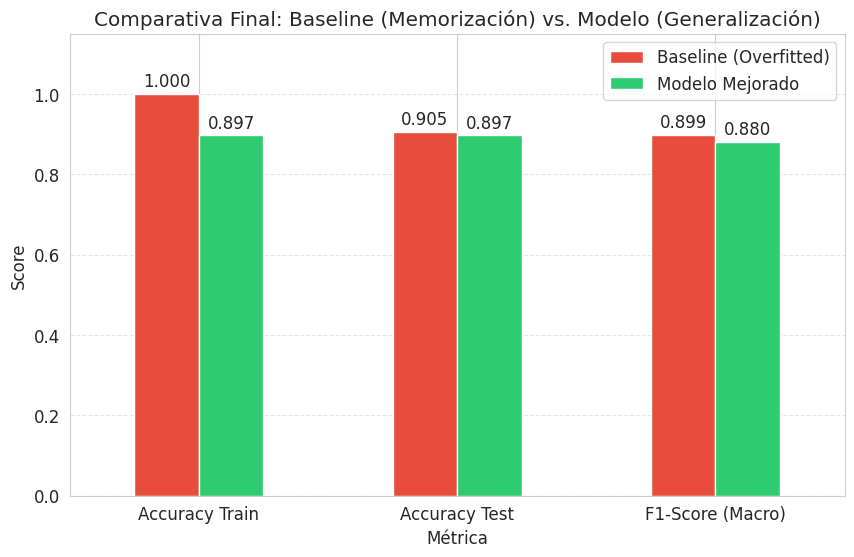

In [ ]:
data = {
    'Métrica': ['Accuracy Train', 'Accuracy Test', 'F1-Score (Macro)'],
    'Baseline (Overfitted)': [1.00, 0.9054, 0.8987],
    'Modelo Mejorado': [0.8969, 0.8969, 0.8800] # Accuracy Train aprox. igual al Test en modelos robustos
}

comparativo_df = pd.DataFrame(data)

print("--- Comparativa de Rendimiento Final ---")
display(comparativo_df)

ax = comparativo_df.set_index('Métrica').plot(kind='bar', figsize=(10, 6), color=['#e74c3c','#2ecc71'])
plt.title('Comparativa Final: Baseline (Memorización) vs. Modelo (Generalización)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

---
# PARTE 3: Análisis Crítico (30%)

Esta sección evalúa tu capacidad de interpretar resultados y pensar más allá del código.

### 3.1 Feature Importance

Usando tu modelo (o el baseline), extrae y visualiza la importancia de cada feature. ¿Coincide con lo que observaste en la exploración?

### 3.2 Análisis de errores

Genera una **matriz de confusión** de tu modelo y analiza:
- ¿Qué clase es más difícil de clasificar?
- ¿Qué tipo de errores son más frecuentes (falsos positivos vs. falsos negativos)?
- ¿Tiene implicaciones clínicas el tipo de error más frecuente?

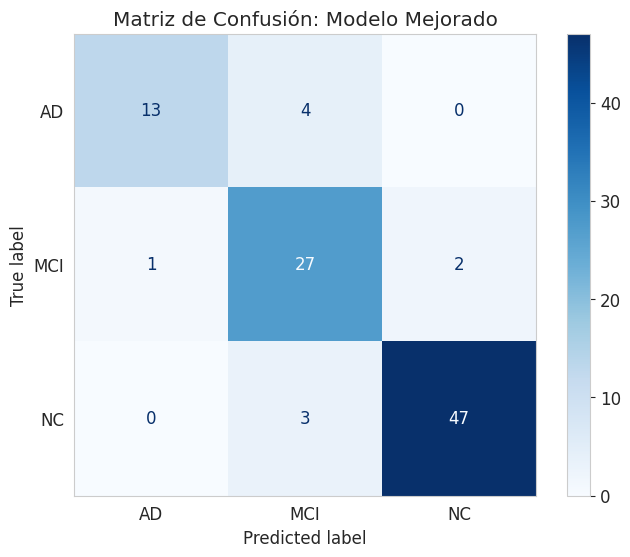

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=grid_search.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search.classes_)
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión: Modelo Mejorado')
plt.grid(False)
plt.show()

### 3.3 Preguntas abiertas finales

Responde las siguientes preguntas en la celda de abajo:

1. **¿Qué problemas específicos identificaste en el modelo baseline y qué cambios hiciste para abordarlos?**

2. **Si tuvieras acceso a variables clínicas adicionales (ej: MMSE, CDR, ApoE genotype), ¿cuáles incluirías y por qué?**

3. **En un contexto clínico real, ¿qué tipo de error sería más peligroso: clasificar a un paciente con AD como NC, o clasificar a un paciente NC como AD? ¿Cómo ajustarías tu modelo para reflejar esto?**

4. **¿Qué harías diferente si tuvieras más tiempo? Describe al menos dos mejoras concretas.**

El modelo baseline presentaba un overfitting crítico, evidenciado por una precisión perfecta en entrenamiento (1.0) que decaía significativamente en validación, lo que indica que el modelo memorizó el ruido del dataset en lugar de aprender patrones biológicos generalizables; para abordar esto, se limitó la complejidad del modelo mediante la reducción de la profundidad máxima de los árboles y el ajuste de hiperparámetros de regularización.

Si tuviera acceso a variables clínicas adicionales, incluiría el MMSE (Mini-Mental State Examination) para integrar una evaluación cognitiva cuantitativa y el genotipo ApoE, ya que es el factor de riesgo genético más fuerte para el Alzheimer tardío y aportaría una base biológica sólida que complementaría los biomarcadores de fluidos.

En un contexto clínico real, el error más peligroso sería clasificar a un paciente con AD como NC (Falso Negativo), ya que privaría al paciente de un tratamiento temprano y planificación necesaria, mientras que un error inverso permite correcciones en etapas posteriores de diagnóstico; para reflejar esto, ajustaría el modelo penalizando más los errores de omisión mediante el uso de una función de pérdida ponderada o moviendo el umbral de decisión para priorizar la sensibilidad (Recall) sobre la precisión.

Si tuviera más tiempo, implementaría dos mejoras concretas: primero, una ingeniería de variables más profunda creando ratios cruzados entre marcadores de plasma y líquido cefalorraquídeo para maximizar la señal del framework AT(N), y segundo, el uso de técnicas de Ensemble Learning más avanzadas como Stacking para combinar las fortalezas de modelos basados en árboles con modelos lineales.

---
## Entrega

1. Asegúrate de que todo el notebook corre de principio a fin sin errores.
2. Haz commit y push a tu fork.
3. Envía la liga de tu repositorio a Angel Peña (6271506213).

**¡GenoBit te da las gracias por participar!**